In [4]:
!sudo apt-get update -qq
!sudo apt-get install -y -qq fonts-nanum > /dev/null 2>&1
!sudo apt-get install -y -qq openjdk-17-jdk-headless > /dev/null 2>&1
!pip install -q konlpy
print('설치 완료')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
설치 완료


In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams['font.family'] = fontprop.get_name()
plt.rcParams['axes.unicode_minus'] = False
print('폰트 설정 완료:', fontprop.get_name())

폰트 설정 완료: NanumBarunGothic


In [6]:
import os, re, tarfile
from collections import Counter
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__)
print('Device:', device)

PyTorch 2.10.0+cu128
Device: cuda


In [7]:
tar_path = None
for c in ['korean-english-park.train.tar.gz',
          '/content/korean-english-park.train.tar.gz',
          'work/korean-english-park.train.tar.gz',
          '/content/drive/MyDrive/korean-english-park.train.tar.gz']:
    if os.path.exists(c):
        tar_path = c
        break
if tar_path is None:
    from google.colab import files
    uploaded = files.upload()
    tar_path = list(uploaded.keys())[0]
print('데이터:', tar_path)

Saving korean-english-park.train.tar.gz to korean-english-park.train.tar.gz
데이터: korean-english-park.train.tar.gz


In [8]:
extract_dir = 'korean-english-park'
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir, exist_ok=True)
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(extract_dir)
    print('압축 해제 완료')
print(os.listdir(extract_dir))

압축 해제 완료
['korean-english-park.train.ko', 'korean-english-park.train.en']


/tmp/ipykernel_5780/3307637326.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_dir)


In [9]:
fl = os.listdir(extract_dir)
kor_file = [f for f in fl if f.endswith('.ko')][0]
eng_file = [f for f in fl if f.endswith('.en')][0]

with open(os.path.join(extract_dir, kor_file), 'r', encoding='utf-8') as f:
    kor_lines = f.read().splitlines()
with open(os.path.join(extract_dir, eng_file), 'r', encoding='utf-8') as f:
    eng_lines = f.read().splitlines()

print('한국어:', len(kor_lines), '문장')
print('영어:', len(eng_lines), '문장')
print()
print('[KOR]', kor_lines[0])
print('[ENG]', eng_lines[0])

한국어: 94123 문장
영어: 94123 문장

[KOR] 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
[ENG] Much of personal computing is about "can you top this?"


In [10]:
pairs = list(set(zip(kor_lines, eng_lines)))
print('중복 제거:', len(kor_lines), '->', len(pairs))

중복 제거: 94123 -> 78968


In [13]:
def preprocess_eng(s):
    s = s.lower().strip()
    s = re.sub(r'([?.!,])', r' \1 ', s)
    s = re.sub(r'[" "]+', ' ', s)
    s = re.sub(r'[^a-zA-Z?.!,]+', ' ', s)
    return s.strip()

def preprocess_kor(s):
    s = s.strip()
    s = re.sub(r'([?.!,])', r' \1 ', s)
    s = re.sub(r'[" "]+', ' ', s)
    s = re.sub(r'[^가-힣a-zA-Z0-9?.!,]+', ' ', s)
    return s.strip()

print(preprocess_kor('안녕!! 날씨 좋네요...'))
print(preprocess_eng('Hello!! GREAT day...'))

안녕 ! ! 날씨 좋네요 . . .
hello ! ! great day . . .


In [14]:
from konlpy.tag import Okt
okt = Okt()
kor_tokenize = lambda s: okt.morphs(s)
print(kor_tokenize('오바마는 대통령이다'))

['오바마', '는', '대통령', '이다']


In [15]:
MAX_TOKEN_LEN = 40
eng_corpus, kor_corpus = [], []

for kor, eng in tqdm(pairs, desc='전처리'):
    if not kor.strip() or not eng.strip():
        continue
    kc = preprocess_kor(kor)
    ec = preprocess_eng(eng)
    if not kc or not ec:
        continue
    kt = kor_tokenize(kc)
    et = ['<start>'] + ec.split() + ['<end>']
    if len(kt) <= MAX_TOKEN_LEN and len(et) <= MAX_TOKEN_LEN:
        kor_corpus.append(kt)
        eng_corpus.append(et)

print('최종 샘플:', len(kor_corpus))
print(kor_corpus[0])
print(eng_corpus[0])

전처리: 100%|██████████| 78968/78968 [04:30<00:00, 291.40it/s]

최종 샘플: 66651
['남아공', '경찰', '은', '관련', '된', '학생', '들', '을', '모두', '기소', '할', '방침', '이다', '.']
['<start>', 'the', 'students', 'involved', 'in', 'the', 'video', 'have', 'been', 'identified', 'and', 'will', 'be', 'suspended', ',', 'fourie', 'said', ',', 'and', 'charges', 'against', 'the', 'men', 'will', 'be', 'filed', 'with', 'the', 'south', 'african', 'police', 'service', '.', '<end>']


In [16]:
class SimpleTokenizer:
    def __init__(self, vocab_size=10000):
        self.vocab_size = vocab_size
        self.pad_id = 0
        self.unk_id = 1
        self.start_id = 2
        self.end_id = 3
        self.pad_token = '<pad>'
        self.unk_token = '<unk>'
        self.start_token = '<start>'
        self.end_token = '<end>'
        self.word2idx = {}
        self.idx2word = {}

    def fit(self, corpus):
        c = Counter()
        for t in corpus:
            c.update(t)
        self.word2idx = {'<pad>':0, '<unk>':1, '<start>':2, '<end>':3}
        for w, _ in c.most_common(self.vocab_size - 4):
            if w not in self.word2idx:
                self.word2idx[w] = len(self.word2idx)
        self.idx2word = {v:k for k,v in self.word2idx.items()}
        self.vocab_size = len(self.word2idx)

    def encode(self, tokens):
        return [self.word2idx.get(t, self.unk_id) for t in tokens]

    def decode(self, ids):
        return [self.idx2word.get(i, self.unk_token) for i in ids]

    def __len__(self):
        return self.vocab_size

print('토크나이저 클래스 정의 완료')

토크나이저 클래스 정의 완료


In [17]:
VOCAB_SIZE = 15000

kor_tokenizer = SimpleTokenizer(VOCAB_SIZE)
kor_tokenizer.fit(kor_corpus)

eng_tokenizer = SimpleTokenizer(VOCAB_SIZE)
eng_tokenizer.fit(eng_corpus)

print('한국어 어휘:', len(kor_tokenizer))
print('영어 어휘:', len(eng_tokenizer))

한국어 어휘: 15000
영어 어휘: 14998


In [18]:
kor_tensor = [kor_tokenizer.encode(t) for t in kor_corpus]
eng_tensor = [eng_tokenizer.encode(t) for t in eng_corpus]

print('[단어]', kor_corpus[0])
print('[숫자]', kor_tensor[0])

[단어] ['남아공', '경찰', '은', '관련', '된', '학생', '들', '을', '모두', '기소', '할', '방침', '이다', '.']
[숫자] [2794, 59, 9, 111, 36, 369, 13, 5, 201, 739, 28, 2288, 39, 4]


In [19]:
class TranslationDataset(Dataset):
    def __init__(self, src, trg, src_tok, trg_tok, max_len):
        self.src = src
        self.trg = trg
        self.pad = src_tok.pad_id
        self.max_len = max_len

    def __len__(self):
        return len(self.src)

    def __getitem__(self, i):
        s = self.src[i][:self.max_len]
        t = self.trg[i][:self.max_len]
        ti = t[:-1]
        tl = t[1:]
        p = self.pad
        s  = s  + [p] * (self.max_len - len(s))
        ti = ti + [p] * (self.max_len - len(ti))
        tl = tl + [p] * (self.max_len - len(tl))
        return torch.tensor(s), torch.tensor(ti), torch.tensor(tl)

MAX_LEN = 40
BATCH = 64
ds = TranslationDataset(kor_tensor, eng_tensor, kor_tokenizer, eng_tokenizer, MAX_LEN)
train_loader = DataLoader(ds, batch_size=BATCH, shuffle=True)

for a, b, c in train_loader:
    print(a.shape, b.shape, c.shape)
    break

torch.Size([64, 40]) torch.Size([64, 40]) torch.Size([64, 40])


In [20]:
class BahdanauAttention(nn.Module):
    def __init__(self, hd):
        super().__init__()
        self.W1 = nn.Linear(hd, hd)
        self.W2 = nn.Linear(hd, hd)
        self.v = nn.Linear(hd, 1, bias=False)

    def forward(self, hidden, enc_out):
        sl = enc_out.shape[0]
        h = hidden.unsqueeze(1).repeat(1, sl, 1)
        e = enc_out.permute(1, 0, 2)
        energy = torch.tanh(self.W1(e) + self.W2(h))
        return nn.functional.softmax(self.v(energy).squeeze(2), dim=1)

print('Attention 정의 완료')

Attention 정의 완료


In [21]:
class Encoder(nn.Module):
    def __init__(self, inp_dim, emb_dim, hid_dim):
        super().__init__()
        self.emb = nn.Embedding(inp_dim, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hid_dim)

    def forward(self, src):
        return self.rnn(self.emb(src))

print('Encoder 정의 완료')

Encoder 정의 완료


In [22]:
class Decoder(nn.Module):
    def __init__(self, out_dim, emb_dim, hid_dim, attn):
        super().__init__()
        self.attn = attn
        self.emb = nn.Embedding(out_dim, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hid_dim)
        self.fc = nn.Linear(hid_dim * 2, out_dim)

    def forward(self, inp, hid, enc_out):
        embedded = self.emb(inp.unsqueeze(0))
        a = self.attn(hid[-1], enc_out).unsqueeze(1)
        ctx = torch.bmm(a, enc_out.permute(1, 0, 2)).permute(1, 0, 2)
        out, hid = self.rnn(embedded, hid)
        pred = self.fc(torch.cat((out.squeeze(0), ctx.squeeze(0)), 1))
        return pred, hid, a.squeeze(1)

print('Decoder 정의 완료')

Decoder 정의 완료


In [23]:
class Seq2Seq(nn.Module):
    def __init__(self, enc, dec, dev):
        super().__init__()
        self.enc = enc
        self.dec = dec
        self.dev = dev

    def forward(self, src, trg=None, max_len=40, sid=2, eid=3):
        bs = src.shape[1]
        outs, atts = [], []
        eo, h = self.enc(src)

        if trg is not None:
            for t in range(trg.shape[0]):
                o, h, a = self.dec(trg[t], h, eo)
                outs.append(o.unsqueeze(0))
                atts.append(a.unsqueeze(0))
        else:
            inp = torch.full((bs,), sid, dtype=torch.long, device=self.dev)
            fin = torch.zeros(bs, dtype=torch.bool, device=self.dev)
            for _ in range(max_len):
                o, h, a = self.dec(inp, h, eo)
                outs.append(o.unsqueeze(0))
                atts.append(a.unsqueeze(0))
                inp = o.argmax(1)
                fin |= (inp == eid)
                if fin.all():
                    break

        return torch.cat(outs, 0), torch.cat(atts, 0)

print('Seq2Seq 정의 완료')

Seq2Seq 정의 완료


In [24]:
IN = len(kor_tokenizer)
OUT = len(eng_tokenizer)
EMB = 256
HID = 512

enc = Encoder(IN, EMB, HID).to(device)
att = BahdanauAttention(HID).to(device)
dec = Decoder(OUT, EMB, HID, att).to(device)
model = Seq2Seq(enc, dec, device).to(device)

print(model)
print('파라미터:', sum(p.numel() for p in model.parameters()))

Seq2Seq(
  (enc): Encoder(
    (emb): Embedding(15000, 256, padding_idx=0)
    (rnn): GRU(256, 512)
  )
  (dec): Decoder(
    (attn): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (emb): Embedding(14998, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (fc): Linear(in_features=1024, out_features=14998, bias=True)
  )
)
파라미터: 25943702


In [25]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)

def train_step(model, loader, opt, crit, ep):
    model.train()
    tot = 0
    bar = tqdm(loader, desc='Epoch ' + str(ep+1), leave=True)
    for s, ti, tl in bar:
        s = s.permute(1, 0).to(device)
        ti = ti.permute(1, 0).to(device)
        tl = tl.permute(1, 0).to(device)
        opt.zero_grad()
        o, _ = model(s, ti)
        loss = crit(o.reshape(-1, o.shape[-1]), tl.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        opt.step()
        tot += loss.item()
        bar.set_postfix(loss=round(loss.item(), 4))
    return tot / len(loader)

def evaluate(sent, model, kt, et, ml=40):
    model.eval()
    tok = kor_tokenize(preprocess_kor(sent))
    ids = kt.encode(tok)[:ml]
    ids += [kt.pad_id] * (ml - len(ids))
    src = torch.tensor(ids).unsqueeze(1).to(device)
    with torch.no_grad():
        o, a = model(src, max_len=ml, sid=et.start_id, eid=et.end_id)
    pred = et.decode(o.argmax(2).squeeze(1).cpu().tolist())
    if et.end_token in pred:
        pred = pred[:pred.index(et.end_token)]
    return pred, tok, a.squeeze(1).cpu().numpy()

print('함수 정의 완료')

함수 정의 완료


In [26]:
examples = [
    ('K1', '오바마는 대통령이다.'),
    ('K2', '시민들은 도시 속에 산다.'),
    ('K3', '커피는 필요 없다.'),
    ('K4', '일곱 명의 사망자가 발생했다.'),
]
for t, s in examples:
    print(t, s)

K1 오바마는 대통령이다.
K2 시민들은 도시 속에 산다.
K3 커피는 필요 없다.
K4 일곱 명의 사망자가 발생했다.


In [27]:
EPOCHS = 10
losses = []
all_tr = []

for ep in range(EPOCHS):
    loss = train_step(model, train_loader, optimizer, criterion, ep)
    losses.append(loss)
    print()
    print('[Epoch', ep+1, '/', EPOCHS, '] Loss:', round(loss, 4))
    res = {}
    for tag, sent in examples:
        r, _, _ = evaluate(sent, model, kor_tokenizer, eng_tokenizer)
        tr = ' '.join(r)
        res[tag] = (sent, tr)
        print(' ', tag, sent, '->', tr)
    all_tr.append({'epoch': ep+1, 'loss': loss, 'tr': res})
    print()

Epoch 1: 100%|██████████| 1042/1042 [06:32<00:00,  2.66it/s, loss=4.71]



[Epoch 1 / 10 ] Loss: 5.1349
  K1 오바마는 대통령이다. -> obama is a great day .
  K2 시민들은 도시 속에 산다. -> the group was <unk> by the city of <unk> , the city s <unk> <unk> .
  K3 커피는 필요 없다. -> the <unk> is not a good .
  K4 일곱 명의 사망자가 발생했다. -> the death toll from the death toll in the city of <unk> , a magnitude .



Epoch 2: 100%|██████████| 1042/1042 [07:04<00:00,  2.46it/s, loss=3.76]



[Epoch 2 / 10 ] Loss: 3.915
  K1 오바마는 대통령이다. -> obama s inauguration is in good shape .
  K2 시민들은 도시 속에 산다. -> the citizens were <unk> by the city s <unk> .
  K3 커피는 필요 없다. -> the coffee is not a coffee .
  K4 일곱 명의 사망자가 발생했다. -> the death toll was killed .



Epoch 3: 100%|██████████| 1042/1042 [07:05<00:00,  2.45it/s, loss=3.12]


...


[Epoch 8 / 10 ] Loss: 1.476
  K1 오바마는 대통령이다. -> obama is the president of the president s name .
  K2 시민들은 도시 속에 산다. -> citizens are citizens in cities in the city .
  K3 커피는 필요 없다. -> it is not known for coffee .
  K4 일곱 명의 사망자가 발생했다. -> seven counties were killed .



Epoch 9: 100%|██████████| 1042/1042 [07:11<00:00,  2.41it/s, loss=1.51]



[Epoch 9 / 10 ] Loss: 1.3213
  K1 오바마는 대통령이다. -> obama is the presidential candidate for president .
  K2 시민들은 도시 속에 산다. -> citizens are civic <unk> in the town city .
  K3 커피는 필요 없다. -> it is not known if it was like coffee , the <unk> .
  K4 일곱 명의 사망자가 발생했다. -> seven of the seven deaths were reported .



Epoch 10: 100%|██████████| 1042/1042 [06:49<00:00,  2.54it/s, loss=1.51]


[Epoch 10 / 10 ] Loss: 1.1957
  K1 오바마는 대통령이다. -> obama is the presidential office .
  K2 시민들은 도시 속에 산다. -> citizens were the mostly or engaged in their lives .
  K3 커피는 필요 없다. -> coffee is needed to win the coffee .
  K4 일곱 명의 사망자가 발생했다. -> seven of the seven deaths were reported .



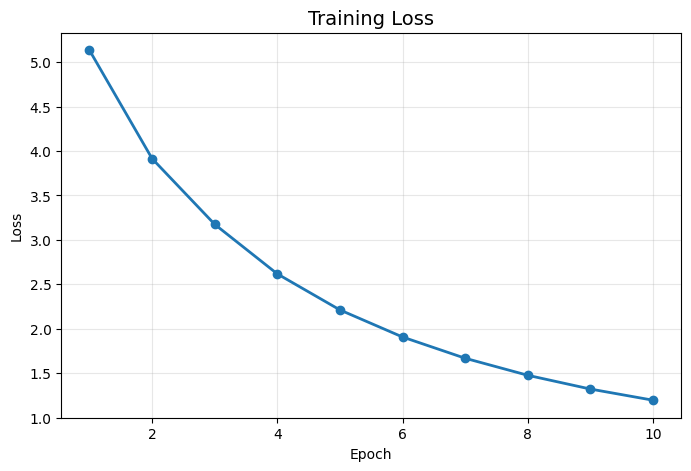

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses)+1), losses, 'o-', lw=2)
plt.title('Training Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

In [29]:
print('## 예문 ##')
for t, s in examples:
    print(t + ')', s)

print()
print('## 제출 ##')
for i, (t, s) in enumerate(examples, 1):
    r, _, _ = evaluate(s, model, kor_tokenizer, eng_tokenizer)
    print('E' + str(i) + ')', ' '.join(r + ['<end>']))

## 예문 ##
K1) 오바마는 대통령이다.
K2) 시민들은 도시 속에 산다.
K3) 커피는 필요 없다.
K4) 일곱 명의 사망자가 발생했다.

## 제출 ##
E1) obama is the presidential office . <end>
E2) citizens were the mostly or engaged in their lives . <end>
E3) coffee is needed to win the coffee . <end>
E4) seven of the seven deaths were reported . <end>


[K1] 오바마는 대통령이다. -> obama is the presidential office .


/tmp/ipykernel_5780/2348393080.py:12: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5780/2348393080.py:12: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


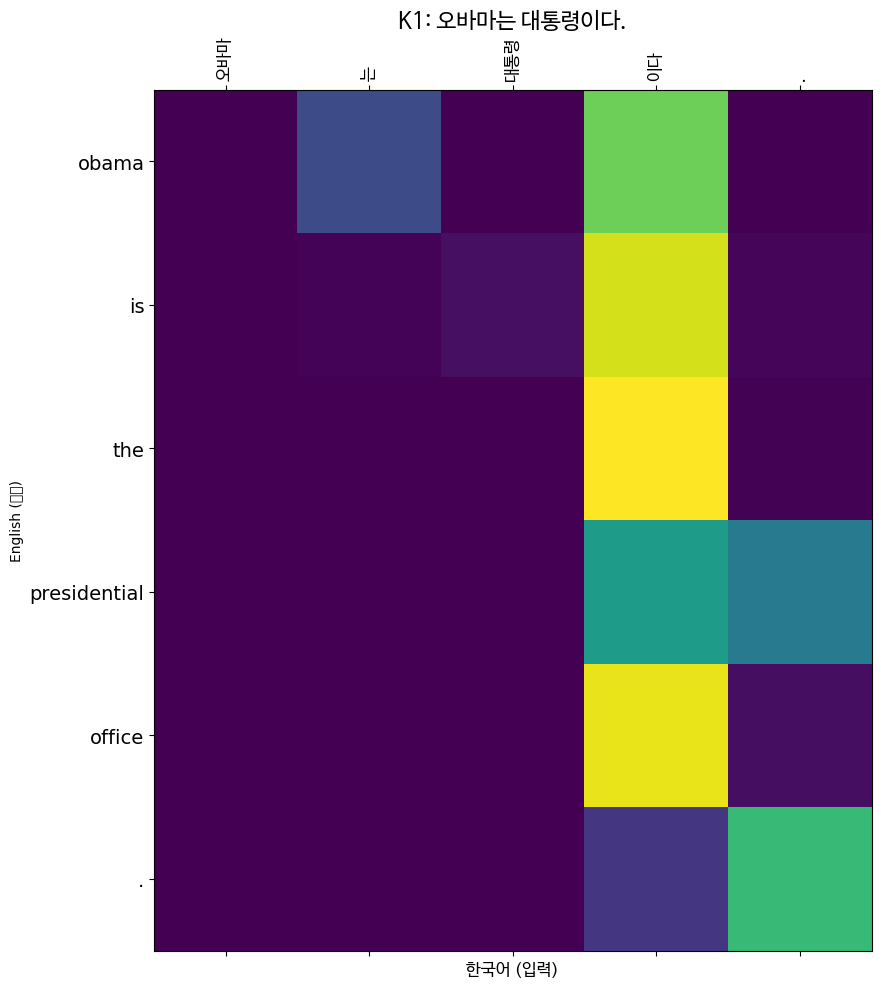


[K2] 시민들은 도시 속에 산다. -> citizens were the mostly or engaged in their lives .


/tmp/ipykernel_5780/2348393080.py:12: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5780/2348393080.py:12: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


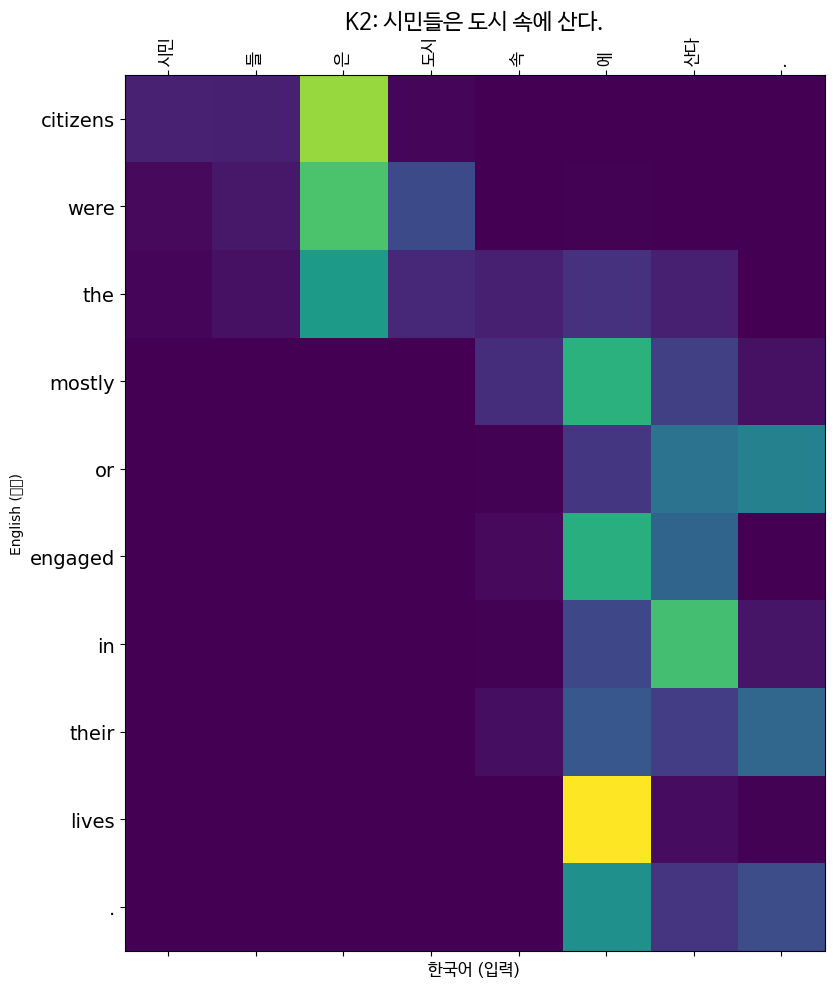


[K3] 커피는 필요 없다. -> coffee is needed to win the coffee .


/tmp/ipykernel_5780/2348393080.py:12: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5780/2348393080.py:12: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


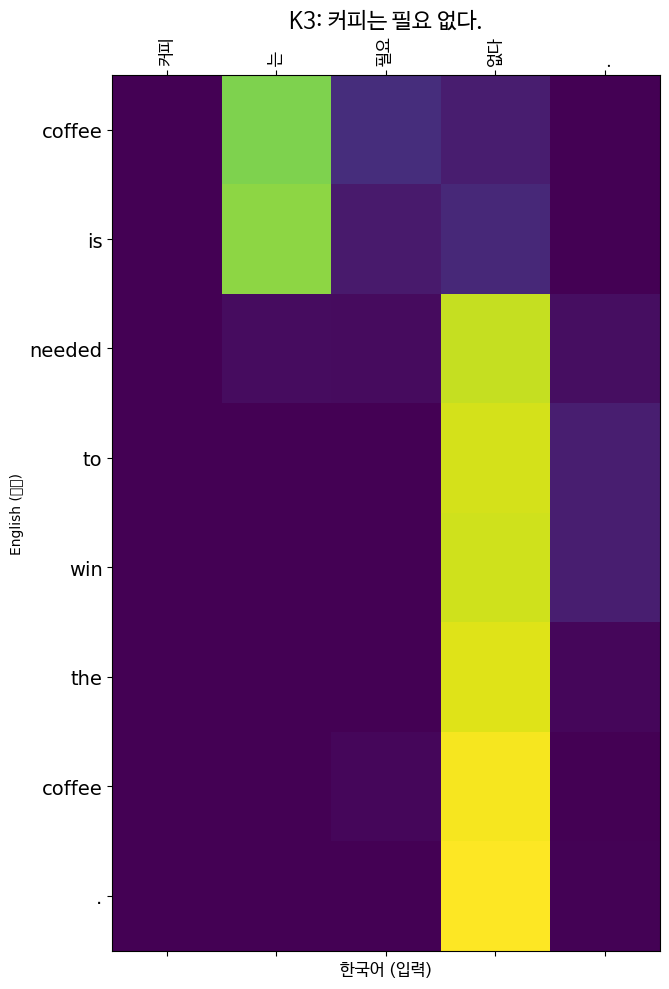


[K4] 일곱 명의 사망자가 발생했다. -> seven of the seven deaths were reported .


/tmp/ipykernel_5780/2348393080.py:12: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5780/2348393080.py:12: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


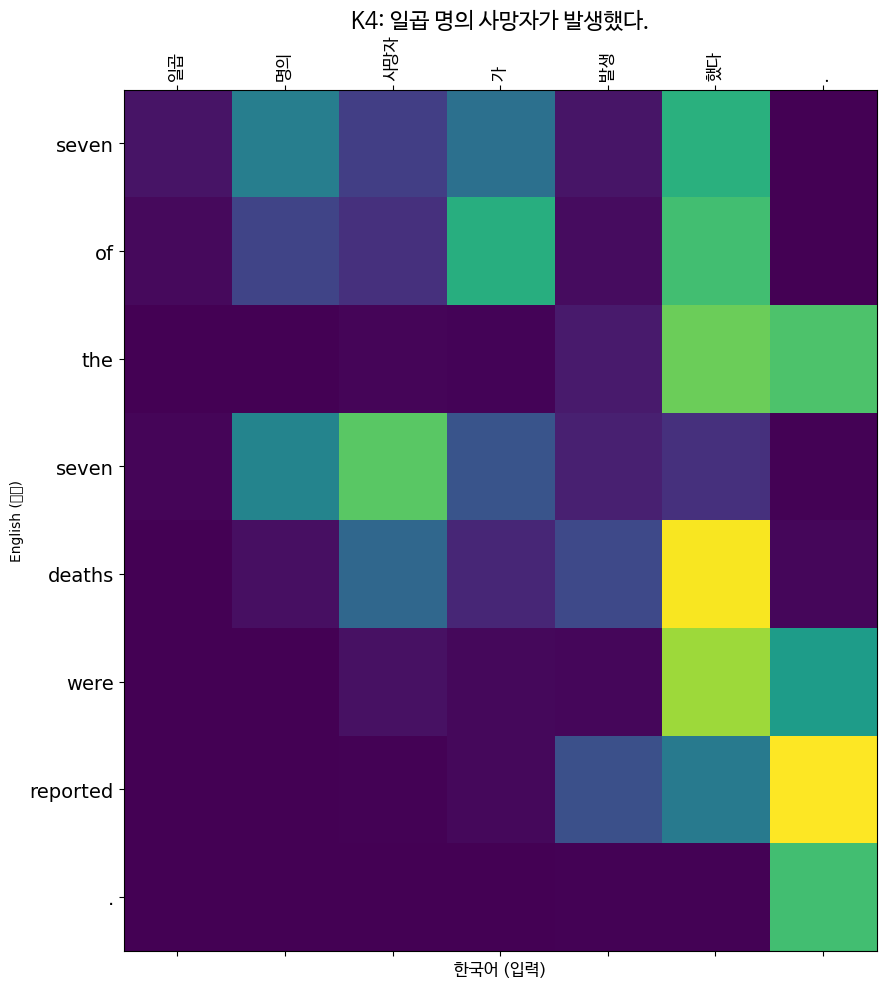

In [30]:
def plot_attention(attn, src_tok, pred_tok, title=''):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attn, cmap='viridis')
    ax.set_xticks(range(len(src_tok)))
    ax.set_xticklabels(src_tok, fontsize=14, rotation=90, fontproperties=fontprop)
    ax.set_yticks(range(len(pred_tok)))
    ax.set_yticklabels(pred_tok, fontsize=14)
    plt.xlabel('한국어 (입력)', fontproperties=fontprop)
    plt.ylabel('English (출력)')
    if title:
        plt.title(title, fontproperties=fontprop, fontsize=16)
    plt.tight_layout()
    plt.show()

for tag, sent in examples:
    res, stok, attn = evaluate(sent, model, kor_tokenizer, eng_tokenizer)
    print('[' + tag + ']', sent, '->', ' '.join(res))
    plot_attention(attn[:len(res), :len(stok)], stok, res, tag + ': ' + sent)
    print()

In [31]:
for rec in all_tr:
    print('[Epoch', rec['epoch'], '] loss =', round(rec['loss'], 4))
    for tag, (s, t) in rec['tr'].items():
        print(' ', tag, t)
    print()

[Epoch 1 ] loss = 5.1349
  K1 obama is a great day .
  K2 the group was <unk> by the city of <unk> , the city s <unk> <unk> .
  K3 the <unk> is not a good .
  K4 the death toll from the death toll in the city of <unk> , a magnitude .

[Epoch 2 ] loss = 3.915
  K1 obama s inauguration is in good shape .
  K2 the citizens were <unk> by the city s <unk> .
  K3 the coffee is not a coffee .
  K4 the death toll was killed .

[Epoch 3 ] loss = 3.1751
  K1 obama is a good president .
  K2 citizens are being carried out by the city .
  K3 coffee is not the first time .
  K4 the death toll from the death toll from the death of the death toll .

[Epoch 4 ] loss = 2.6174
  K1 obama is the best way to go to the polls today
  K2 citizens are often used in cities .
  K3 coffee is coffee at the coffee .
  K4 seven people were killed .

[Epoch 5 ] loss = 2.2117
  K1 obama is the president of the president s name .
  K2 citizens were handed over to the city .
  K3 it s not a coffee retailer .
  K4 seven

##회고 : 전처리가 중요했다. 전처리를 제대로 해야 모델이 학습을 잘 한다는걸 배웠다. 특히 중복문제에서 중요했다.